# Water tank control

Jypyter NoteBook demonstrates the execution of the **FMU Co-Simulation** simulation sample.<br>

<div style="display: flex;">
  <div style="flex: 1; padding: 10px;">
    <img src="FMU_Cosim_diagrams/overview.jpg" alt="Overview" width="100%"/>
  </div>
  <div style="flex: 1; padding: 10px;">
    <img src="FMU_Cosim_diagrams/simconfig.jpg" alt="Details" width="100%"/>
  </div>
</div>


To install the pyST.zip use the following command: <code>$ pip install pyST.zip<code>

To run this NoteBook, follow the provided steps:<br>
**Step 1:** Create a client by providing the TWC server, user name and password. <br>
<code>client = SimulationWebClient('TWC_server', 'user_name', 'user_psw', verifySSL=False)</code><br>
<i>Note: If 'user_psw' is not entered, an input field is provided to enter a password.</i>

In [1]:
# Disable SSL warnings
import urllib3
import json
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [2]:
# Create client
from pyST import SimulationWebClient
client = SimulationWebClient('https://<TWC>:8443/', '<username>', '<passwd>', verifySSL=False)

In [3]:
sysml_desc = client.get_descriptor('FMU-Co-simulation', config='SysML analysis')
fmu_desc = client.get_descriptor('FMU-Co-simulation', config='FMU analysis')

print(sysml_desc)
print(fmu_desc)

{'config': 'SysML analysis', 'model': 'System SysML', 'timeStep': '50.0 ms', 'parameters': {'inputs': [{'parameter': 'control.maxlevel', 'value': 3.0, 'type': 'Real'}, {'parameter': 'control.minlevel', 'value': 1.0, 'type': 'Real'}, {'parameter': 'waterTank.flowRate', 'value': 0.2, 'type': 'Real'}], 'outputs': [{'parameter': 'waterTank.flowRate', 'value': 0.2, 'type': 'Real'}, {'parameter': 'waterTank.valvestate', 'type': 'Real'}, {'parameter': 'waterTank.waterlevel', 'type': 'Real'}]}}
{'config': 'FMU analysis', 'model': 'FMU Implementation', 'timeStep': '50.0 ms', 'parameters': {'inputs': [{'parameter': 'control.maxlevel', 'value': 3.0, 'type': 'Real'}, {'parameter': 'control.minlevel', 'value': 1.0, 'type': 'Real'}, {'parameter': 'waterTank.flowRate', 'value': 0.2, 'type': 'Real'}], 'outputs': [{'parameter': 'waterTank.flowRate', 'value': 0.2, 'type': 'Real'}, {'parameter': 'waterTank.valvestate', 'type': 'Real'}, {'parameter': 'waterTank.waterlevel', 'type': 'Real'}]}}


**Step 3** Run the following cells.<br><br>
<i>Note: **Simulate()** starts a simulation and returns its results.</i><br>
<code>simulate('project', config='config', version='version', branch='branch', element_id='element_id', commit_results='True/False', verification='All/None/Fail', data=json.dumps('param'))</code>

In [4]:
# Run simulation
parameters = {
  "inputs":
  {
    "waterTank.flowRate": 0.3,
    "control.maxlevel": 3.0,
    "control.minlevel": 1.0
  }
}

result_sysml = client.simulate('FMU-Co-simulation', config='SysML analysis', commit_results=False, data=json.dumps(parameters))
result_fmu = client.simulate('FMU-Co-simulation', config='FMU analysis', commit_results=False, data=json.dumps(parameters))
#simID = result['simulationId']
#status = client.get_status(simID)
#print(status)

In [5]:
watertanklLevel_sysml = result_sysml['outputs']['waterTank.level']
csv_sysml = result_sysml['csvExports']['watertanklevel']
watertanklLevel_fmu = result_fmu['outputs']['waterTank.level']
csv_fmu = result_fmu['csvExports']['watertanklevel']

In [6]:
#client.terminate(simID)
print(watertanklLevel_sysml)
print(csv_sysml)
print(watertanklLevel_fmu)
print(csv_fmu)

1.9199999999999915
time(ms),flowRate,level,valve
0.0000,0.3000,0.0000,0.0000
50.0000,0.3000,0.0000,0.0000
100.0000,0.3000,0.3000,0.0000
150.0000,0.3000,0.3000,0.0000
200.0000,0.3000,0.6000,0.0000
250.0000,0.3000,0.6000,0.0000
300.0000,0.3000,0.9000,0.0000
350.0000,0.3000,0.9000,0.0000
400.0000,0.3000,1.2000,0.0000
450.0000,0.3000,1.2000,0.0000
500.0000,0.3000,1.5000,0.0000
550.0000,0.3000,1.5000,0.0000
600.0000,0.3000,1.8000,0.0000
650.0000,0.3000,1.8000,0.0000
700.0000,0.3000,2.1000,0.0000
750.0000,0.3000,2.1000,0.0000
800.0000,0.3000,2.4000,0.0000
850.0000,0.3000,2.4000,0.0000
900.0000,0.3000,2.7000,0.0000
950.0000,0.3000,2.7000,0.0000
1000.0000,0.3000,3.0000,0.0000
1050.0000,0.3000,3.0000,0.0000
1100.0000,0.3000,3.3000,1.0000
1150.0000,0.3000,3.3000,1.0000
1200.0000,0.3000,3.2400,1.0000
1250.0000,0.3000,3.2400,1.0000
1300.0000,0.3000,3.1800,1.0000
1350.0000,0.3000,3.1800,1.0000
1400.0000,0.3000,3.1200,1.0000
1450.0000,0.3000,3.1200,1.0000
1500.0000,0.3000,3.0600,1.0000
1550.0000,0.3

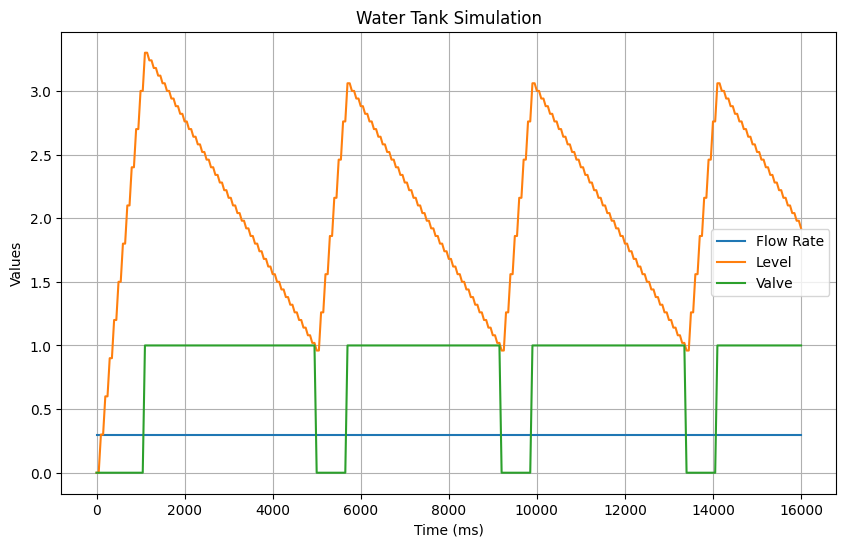

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# your CSV string
data = csv_sysml

# parse the CSV string
df = pd.read_csv(io.StringIO(data))

# convert time(ms) to numeric
df['time(ms)'] = pd.to_numeric(df['time(ms)'])

# plot
plt.figure(figsize=(10, 6))
plt.plot(df['time(ms)'], df['flowRate'], label='Flow Rate')
plt.plot(df['time(ms)'], df['level'], label='Level')
plt.plot(df['time(ms)'], df['valve'], label='Valve')

plt.xlabel('Time (ms)')
plt.ylabel('Values')
plt.title('Water Tank Simulation')
plt.legend()
plt.grid(True)
plt.show()


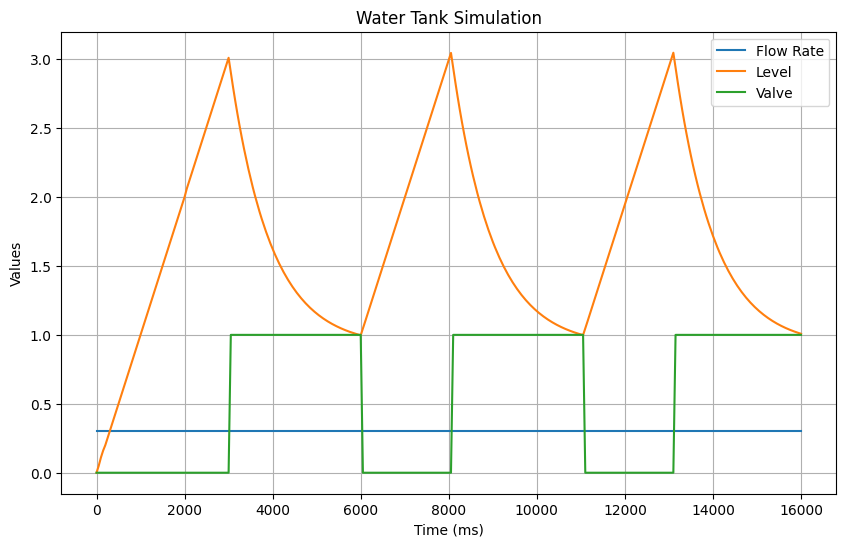

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# your CSV string
data = csv_fmu

# parse the CSV string
df = pd.read_csv(io.StringIO(data))

# convert time(ms) to numeric
df['time(ms)'] = pd.to_numeric(df['time(ms)'])

# plot
plt.figure(figsize=(10, 6))
plt.plot(df['time(ms)'], df['flowRate'], label='Flow Rate')
plt.plot(df['time(ms)'], df['level'], label='Level')
plt.plot(df['time(ms)'], df['valve'], label='Valve')

plt.xlabel('Time (ms)')
plt.ylabel('Values')
plt.title('Water Tank Simulation')
plt.legend()
plt.grid(True)
plt.show()
